In [ ]:
import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("file")), "code", "benchmark_networks"))

import numpy as np
import matplotlib.pyplot as plt
import importlib
import data_prepare
importlib.reload(data_prepare)
from data_prepare import prepare_data

# ============================================================
# Load Data
# ============================================================

data_dir = "./data"

EEG = np.load(f"{data_dir}/EEG_all_epochs.npy", allow_pickle=True)
EOG = np.load(f"{data_dir}/EOG_all_epochs.npy", allow_pickle=True)
EMG = np.load(f"{data_dir}/EMG_all_epochs.npy", allow_pickle=True)


# Denoising data after recording

In [2]:
# prepare the data using the provided function
EEG = np.array(EEG.tolist(), dtype=np.float32)
EOG = np.array(EOG.tolist(), dtype=np.float32)
EMG = np.array(EMG.tolist(), dtype=np.float32)

print(f"Originele groottes — EEG: {len(EEG)}, EOG: {len(EOG)}, EMG: {len(EMG)}")

# Afkappen zodat EEG en noise even groot zijn
n_eog = min(len(EEG), len(EOG))
n_emg = min(len(EEG), len(EMG))

# EOG dataset: clean EEG + EOG artefact
noisy_eog_train, clean_eog_train, noisy_eog_val, clean_eog_val, noisy_eog_test, clean_eog_test, std_eog, ref_eog_test = \
    prepare_data(EEG_all=EEG[:n_eog], noise_all=EOG[:n_eog], combin_num=10, train_per=0.8, noise_type='EOG')

# EMG dataset: clean EEG + EMG artefact
noisy_emg_train, clean_emg_train, noisy_emg_val, clean_emg_val, noisy_emg_test, clean_emg_test, std_emg, ref_emg_test = \
    prepare_data(EEG_all=EEG[:n_emg], noise_all=EMG[:n_emg], combin_num=10, train_per=0.8, noise_type='EMG')

print("EOG — train:", noisy_eog_train.shape, "| val:", noisy_eog_val.shape, "| test:", noisy_eog_test.shape)
print("EMG — train:", noisy_emg_train.shape, "| val:", noisy_emg_val.shape, "| test:", noisy_emg_test.shape)

Originele groottes — EEG: 4514, EOG: 3400, EMG: 5598
(27200,)
training data prepared (27200, 512) (27200, 512)
validation data prepared, validation data shape:  (3400, 512) (3400, 512)
test data prepared, test data shape:  (3400, 512) (3400, 512)
(36110,)
training data prepared (36110, 512) (36110, 512)
validation data prepared, validation data shape:  (4520, 512) (4520, 512)
test data prepared, test data shape:  (4510, 512) (4510, 512)
EOG — train: (27200, 512) | val: (3400, 512) | test: (3400, 512)
EMG — train: (36110, 512) | val: (4520, 512) | test: (4510, 512)


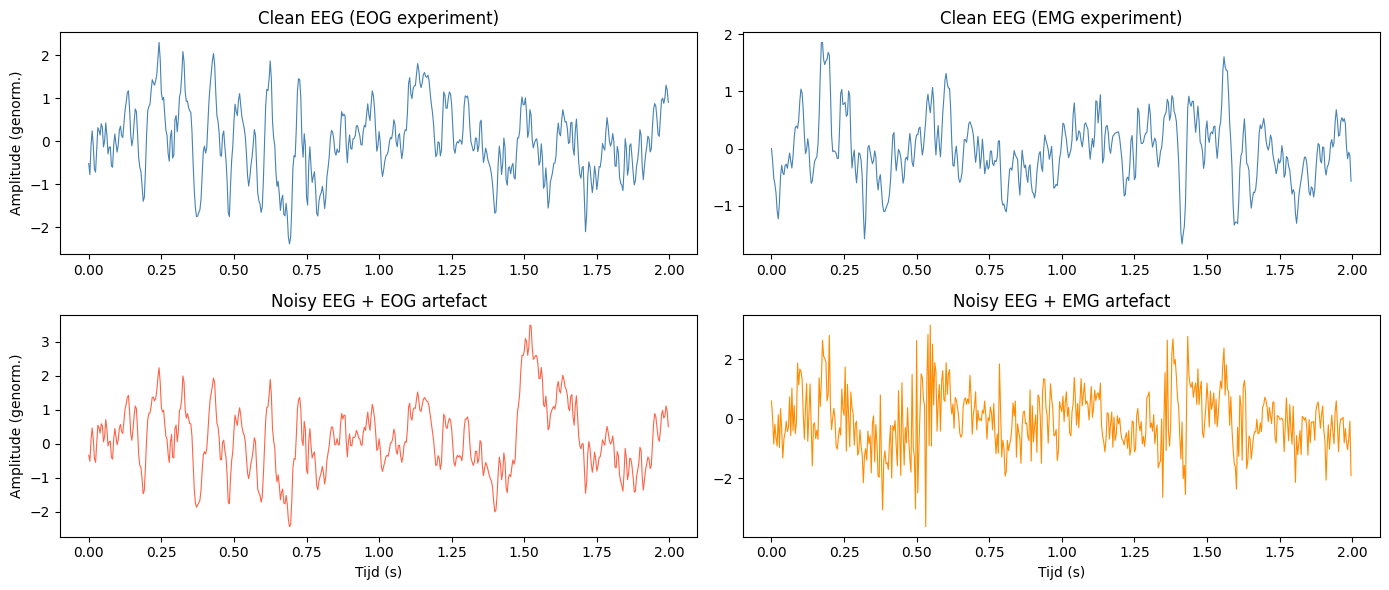

In [3]:
# plot signals
fs = 256
t = np.arange(512) / fs

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# EOG
axes[0, 0].plot(t, clean_eog_train[0], color="steelblue", linewidth=0.8)
axes[0, 0].set_title("Clean EEG (EOG experiment)")
axes[0, 0].set_ylabel("Amplitude (genorm.)")

axes[1, 0].plot(t, noisy_eog_train[0], color="tomato", linewidth=0.8)
axes[1, 0].set_title("Noisy EEG + EOG artefact")
axes[1, 0].set_ylabel("Amplitude (genorm.)")
axes[1, 0].set_xlabel("Tijd (s)")

# EMG
axes[0, 1].plot(t, clean_emg_train[0], color="steelblue", linewidth=0.8)
axes[0, 1].set_title("Clean EEG (EMG experiment)")

axes[1, 1].plot(t, noisy_emg_train[0], color="darkorange", linewidth=0.8)
axes[1, 1].set_title("Noisy EEG + EMG artefact")
axes[1, 1].set_xlabel("Tijd (s)")

plt.tight_layout()
plt.show()

## Code for evaluation


In [4]:
import numpy as np

# uses RRMSE and Pearson Correlation for evaluation
def evaluate(clean, denoised, naam=""):
    rrmse = np.sqrt(np.mean((clean - denoised) ** 2) / np.mean(clean ** 2))
    corr  = np.mean([np.corrcoef(clean[i], denoised[i])[0, 1] for i in range(len(clean))])
    print(f"{naam} — RRMSE: {rrmse:.4f} | Correlatie: {corr:.4f}")


# plot to visualise and compare both signals. Use both test datasets
# example usage:
    # plot_denoising(clean_eog_test, denoised_eog_test, "ICA — EOG")
    # plot_denoising(clean_emg_test, denoised_emg_test, "ICA — EMG")

def plot_denoising(clean, denoised, titel="", fs=256, idx=0):
    t = np.arange(clean.shape[1]) / fs
    plt.figure(figsize=(10, 3))
    plt.plot(t, clean[idx],    color="steelblue",  linewidth=0.8, label="Clean EEG")
    plt.plot(t, denoised[idx], color="tomato",      linewidth=0.8, label="Denoised", alpha=0.8)
    plt.title(titel)
    plt.xlabel("Tijd (s)")
    plt.ylabel("Amplitude (genorm.)")
    plt.legend()
    plt.tight_layout()
    plt.show()



## ICA


Independent Component Analysis (ICA) is a really popular classical blind source separation method. It assumes the observed signal is a linear mixture of independent sources and attempts to separate them without prior knowledge of their origin.

In EEG research, ICA is the standard method for artifact removal: artifacts such as eye movements (EOG) and muscle activity (EMG) manifest as statistically independent components that can be identified and removed. We use ICA here as a baseline offline method, as it is the most widely used classical approach in the literature.

A key limitation is that ICA is designed for multichannel EEG, where spatial information across multiple electrodes is used to separate sources. Applied to single-channel data — as in this dataset — epochs are treated as channels, which severely limits the separation power. Performance is therefore expected to be lower than in multichannel settings.

In [ ]:
from sklearn.decomposition import FastICA
from scipy.stats import kurtosis
import numpy as np

def ica_denoise(noisy_train, noisy_eval, n_components=20, n_exclude=4, fun='logcosh'):
    ica = FastICA(n_components=n_components, fun=fun, random_state=42,
                  max_iter=1000, whiten='unit-variance')
    ica.fit(noisy_train)

    sources = ica.transform(noisy_eval)
    kurt = kurtosis(sources, axis=0, fisher=True)
    exclude_idx = np.argsort(np.abs(kurt))[::-1][:n_exclude]

    sources_clean = sources.copy()
    sources_clean[:, exclude_idx] = 0

    return ica.inverse_transform(sources_clean), ica

### Optuna for hyperparameter tuning

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(noisy_train, noisy_val, clean_val):
    def objective(trial):
        n_components = trial.suggest_int('n_components', 8, 32)
        n_exclude    = trial.suggest_int('n_exclude', 1, n_components - 1)
        fun          = trial.suggest_categorical('fun', ['logcosh', 'exp', 'cube'])
        denoised_val, _ = ica_denoise(noisy_train, noisy_val, n_components, n_exclude, fun)
        return np.sqrt(np.mean((clean_val - denoised_val)**2) / np.mean(clean_val**2))
    return objective

c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


EOG beste params: {'n_components': 25, 'n_exclude': 24, 'fun': 'cube'}
EOG beste RRMSE:  1.1170294653940678
EMG beste params: {'n_components': 28, 'n_exclude': 2, 'fun': 'cube'}
EMG beste RRMSE:  0.9113736040820689
EOG — RRMSE: 1.1166 | Correlatie: 0.0519
EMG — RRMSE: 0.9114 | Correlatie: 0.5269


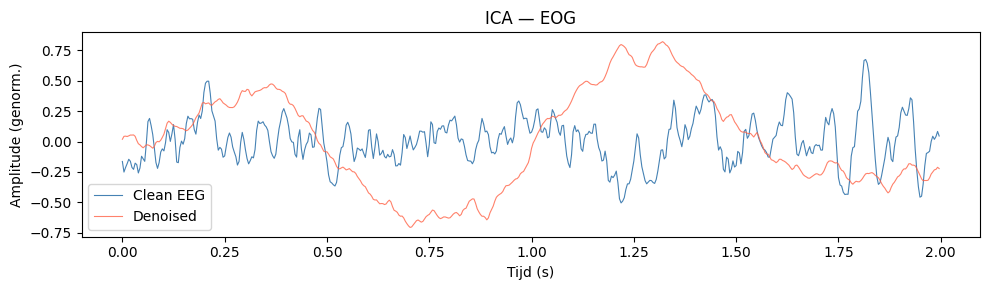

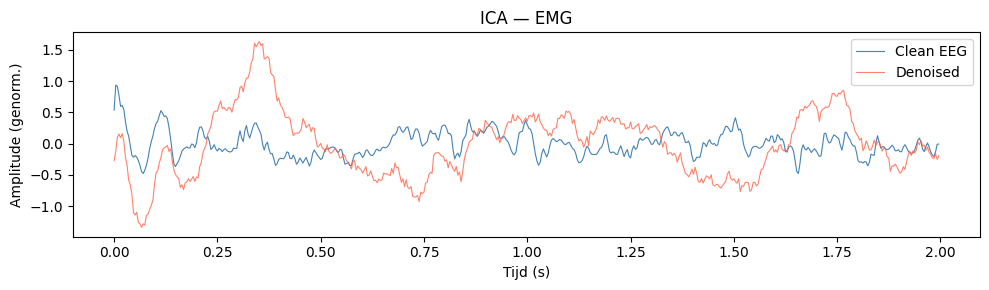

In [ ]:
# start optuna hyperparameter tuning 
study_eog = optuna.create_study(direction='minimize')
study_eog.optimize(make_objective(noisy_eog_train, noisy_eog_val, clean_eog_val), n_trials=20)

study_emg = optuna.create_study(direction='minimize')
study_emg.optimize(make_objective(noisy_emg_train, noisy_emg_val, clean_emg_val), n_trials=20)

print("EOG beste params:", study_eog.best_params)
print("EOG beste RRMSE: ", study_eog.best_value)

print("EMG beste params:", study_emg.best_params)
print("EMG beste RRMSE: ", study_emg.best_value)

# train with best hyperparameters and evaluate 
denoised_eog_test, _ = ica_denoise(noisy_eog_train, noisy_eog_test, **study_eog.best_params)
evaluate(clean_eog_test, denoised_eog_test, "EOG")

denoised_emg_test, _ = ica_denoise(noisy_emg_train, noisy_emg_test, **study_emg.best_params)
evaluate(clean_emg_test, denoised_emg_test, "EMG")

# plot the results 
plot_denoising(clean_eog_test, denoised_eog_test, "ICA — EOG")
plot_denoising(clean_emg_test, denoised_emg_test, "ICA — EMG")

### Result

The ICA results are poor for both artifact types. For EOG, the RRMSE of 1.12 indicates the denoised signal is worse than the original noisy signal(RRMSE > 1), and the correlation of 0.06 confirms almost no resemblance to the clean EEG. The plot clearly shows the signals diverge significantly.

For EMG, results are slightly better (RRMSE: 0.91, correlation: 0.52), but still far from acceptable thresholds.

The poor performance is expected: ICA is fundamentally designed for multichannel EEG, where it separates sources across electrodes. Applied to single-channel data by treating epochs as channels, it cannot properly identify and isolate artifact components.

##  One-Dimentional Residual Convolutional Neural Network

The 1-Dimensional Residual Convolutional Neural Network (1D-ResCNN) is a deep learning architecture for time-series data, proposed as part of the EEGDenoiseNet benchmark by Zhang et al. (2021). Unlike some other methods, it learns directly from data: given pairs of noisy and clean signals, it trains convolutional filters to learn how to filter out the noise on its own without any prior knowledge about their frequency or statistical properties.

Its architecture relies on a stack of residual blocks with shortcut connections: rather than forcing the network to learn what a clean EEG looks like from scratch, we save a copy of the clean EEG before doing anything, so each block only needs to learn what specific noise to remove. This makes the filtering process highly accurate and prevents the network from accidentally deleting true brainwave activity.

A key advantage of this approach is that it works really well on single-channel recordings. Instead of needing data from multiple electrodes to cross-reference the noise, it gets rid of noise purely by analyzing how the wave changes over time. While the network does require a computationally expensive offline training phase, the resulting model is highly effective, especially in scenarios where the noise and true brainwave frequencies heavily overlap.

### create untrained neural network

In [5]:
import torch
import torch.nn as nn

# standard 1D residual block (nn.module to inherit from PyTorch's base class for all NN's)
class ResBlock1D(nn.Module):
    # constructor:
    # - channels: number of datastreams
    # - kernel_size: number of data points "sliding window" looks at at a time
    # - padding: add fake zero's at the edges of the data so "sliding window" doesn't accidently shrink data
    def __init__(self, channels, kernel_size=5, padding=2):
        super(ResBlock1D, self).__init__()
        # initialize convolution (filter): "sliding window" that hunts for noise patterns
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding)
        # initialize batch normalization (stabilizer): scales numbers so they don't get too big/small
        self.bn1 = nn.BatchNorm1d(channels)
        # initialize relu (activator): turn negative numbers into 0, leave positive numbers alone (introduces non-linearity)
        self.relu = nn.ReLU(inplace=True)
        # initialize second convolution
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding)
        # initialize second batch normalization
        self.bn2 = nn.BatchNorm1d(channels)

    # how data moves through the block
    def forward(self, x):
        # save original input
        residual = x

        # pass the data through the layers to isolate the noise
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # add untouched data back into filtered data to restore frequencies the filters might have accidently gotten rid of
        out += residual
        # final activation
        out = self.relu(out)

        return out

# full model:
class ResCNN(nn.Module):
    # constructor:
    # - channel = 1 cause EEG is single-channel
    # - num_features = 64 cause we expand stream into 64 parallel paths
    # - num_blocks = 4 cause 4 residual blocks will be stacked
    def __init__(self, in_channels=1, num_features=64, num_blocks=4):
        super(ResCNN, self).__init__()

        # expands the 1 channel input into 64 feature channels
        self.initial_conv = nn.Conv1d(in_channels, num_features, kernel_size=7, padding=3)
        # stabelize input data
        self.bn_initial = nn.BatchNorm1d(num_features)
        # activate input data
        self.relu = nn.ReLU(inplace=True)

        # creates a sequence of 4 residual blocks and chain them together
        blocks = []
        for _ in range(num_blocks):
            blocks.append(ResBlock1D(channels=num_features))
        self.res_blocks = nn.Sequential(*blocks)

        # compress the 64 feature channels back down to 1 clean EEG channel
        self.final_conv = nn.Conv1d(num_features, in_channels, kernel_size=7, padding=3)

    # how data moves through the model
    def forward(self, x):
        # pass the data through the layers (expands into 64 channels)
        out = self.initial_conv(x)
        out = self.bn_initial(out)
        out = self.relu(out)

        # pass the data through all residual blocks in sequence
        out = self.res_blocks(out)

        # compress data back down to 1 clean EEG channel
        out = self.final_conv(out)
        return out

### reshape data

Neural networks only accept 3D blocks of data, but currently we are working with 2D blocks of data. Therefore, the data has to be repackaged in order for this model to be able to use it.

In [6]:
from torch.utils.data import DataLoader, TensorDataset

# helper function: repackage the numpy arrays into pytorch dataloaders
def make_loaders(noisy_train, clean_train, noisy_val, clean_val, batch_size):
    # prepare the data from numpy "language" to tensor "language"
    def to_tensor(arr):
        # .unsqueeze(1) takes 2D array and puts "1" in the middle dimension to make it 3D
        return torch.tensor(arr, dtype=torch.float32).unsqueeze(1)

    # package noisy and clean training data together
    train_ds = TensorDataset(to_tensor(noisy_train), to_tensor(clean_train))
    # package noisy and clean validation data together
    val_ds = TensorDataset(to_tensor(noisy_val), to_tensor(clean_val))

    # create the dataloaders (shuffle training data so the model learns better)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds,   batch_size=batch_size)

    return train_loader, val_loader

### train model

In [11]:
# # training function
# def train_rescnn(noisy_train, clean_train, noisy_val, clean_val, num_features=64, num_blocks=4, lr=1e-3, epochs=50, batch_size=256):
#     # reshape the data
#     train_loader, val_loader = make_loaders(noisy_train, clean_train, noisy_val, clean_val, batch_size)

#     # initialize model
#     model = ResCNN(num_features=num_features, num_blocks=num_blocks)
#     # initialize optimizer (adam is a well-used learning algorithm)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     # create criterion (grades how close the cleaned EEG is to the true EEG, use mean squared error)
#     criterion = nn.MSELoss()

#     # initialize best score
#     best_score = float("inf")
#     # initialize best state (settings when model gets high score)
#     best_state = None

#     print("start training...")

#     # main training loop
#     # for every epoch
#     for epoch in range(epochs):
#         # train the model
#         model.train()
#         # for every batch of noisy+clean training data
#         for noisy_batch, clean_batch in train_loader:
#             # forget previous batch
#             optimizer.zero_grad()

#             # denoise the data by putting noisy data through model
#             denoised_batch = model(noisy_batch)

#             # grader compares model's clean data to actual clean data and grades is (high score = bad)
#             loss = criterion(denoised_batch, clean_batch)

#             # pytorch traces mistakes to figure out which filter caused them
#             loss.backward()
#             # adjust those filters to get better result next batch
#             optimizer.step()

#         # set model to evaluation mode
#         model.eval()
#         # create array with actual clean EEG, create array with model's denoised EEG
#         all_clean, all_denoised = [], []

#         # stop tracking mistakes
#         with torch.no_grad():
#             # for every batch of noisy+clean validation data
#             for noisy_batch, clean_batch in val_loader:
#                 # clean the noisy validation data and convert straight to numpy 2D array
#                 denoised = model(noisy_batch).numpy().squeeze(1)

#                 # append the data to their respective arrays
#                 all_clean.append(clean_batch.numpy().squeeze(1))
#                 all_denoised.append(denoised)

#         # concatenate validation batches back together to calculate final score
#         clean_np = np.concatenate(all_clean)
#         denoised_np = np.concatenate(all_denoised)

#         # calculate RRMSE
#         val_rrmse = np.sqrt(np.mean((clean_np - denoised_np) ** 2) / np.mean(clean_np ** 2))

#         # if this is the best score so far, save the score and a copy of the models settings
#         if val_rrmse < best_score:
#             best_score = val_rrmse
#             best_state = {k: v.clone() for k, v in model.state_dict().items()}

#         # print epoch number and current val RRMSE every 10 epochs
#         if (epoch + 1) % 10 == 0:
#             print(f"Epoch {epoch} | Validation RRMSE: {val_rrmse}")

#     # when training is done, reload best settings we found and return the model and best score
#     model.load_state_dict(best_state)
#     print("Best RRMSE:", best_score)
#     return model, best_score


# # helper function: take noisy numpy array and fully trained model and use model to clean data in array
# def rescnn_denoise(model, noisy_test):
#     # set model to evaluation mode
#     model.eval()
#     # prepare the data for the NN model
#     t = torch.tensor(noisy_test, dtype=torch.float32).unsqueeze(1)
#     # stop tracking mistakes
#     with torch.no_grad():
#         # use model to clean data, turn clean data into 2D numpy array
#         out = model(t).numpy().squeeze(1)
#     return out

# Setup device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# training function
def train_rescnn(noisy_train, clean_train, noisy_val, clean_val, num_features=64, num_blocks=4, lr=1e-3, epochs=50, batch_size=256):
    # reshape the data
    train_loader, val_loader = make_loaders(noisy_train, clean_train, noisy_val, clean_val, batch_size)

    # initialize model
    model = ResCNN(num_features=num_features, num_blocks=num_blocks).to(device)
    # initialize optimizer (adam is a well-used learning algorithm)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # create criterion (grades how close the cleaned EEG is to the true EEG, use mean squared error)
    criterion = nn.MSELoss()

    # initialize best score
    best_score = float("inf")
    # initialize best state (settings when model gets high score)
    best_state = None

    print("start training...")

    # main training loop
    # for every epoch
    for epoch in range(epochs):
        # train the model
        model.train()
        # for every batch of noisy+clean training data
        for noisy_batch, clean_batch in train_loader:
            # Move batches to device
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.to(device)

            # forget previous batch
            optimizer.zero_grad()

            # denoise the data by putting noisy data through model
            denoised_batch = model(noisy_batch)

            # grader compares model's clean data to actual clean data and grades is (high score = bad)
            loss = criterion(denoised_batch, clean_batch)

            # pytorch traces mistakes to figure out which filter caused them
            loss.backward()
            # adjust those filters to get better result next batch
            optimizer.step()

        # set model to evaluation mode
        model.eval()
        # create array with actual clean EEG, create array with model's denoised EEG
        all_clean, all_denoised = [], []

        # stop tracking mistakes
        with torch.no_grad():
            # for every batch of noisy+clean validation data
            for noisy_batch, clean_batch in val_loader:
                # clean the noisy validation data and convert straight to numpy 2D array
                denoised = model(noisy_batch.to(device)).cpu().numpy().squeeze(1)

                # append the data to their respective arrays
                all_clean.append(clean_batch.numpy().squeeze(1))
                all_denoised.append(denoised)

        # concatenate validation batches back together to calculate final score
        clean_np = np.concatenate(all_clean)
        denoised_np = np.concatenate(all_denoised)

        # calculate RRMSE
        val_rrmse = np.sqrt(np.mean((clean_np - denoised_np) ** 2) / np.mean(clean_np ** 2))

        # if this is the best score so far, save the score and a copy of the models settings
        if val_rrmse < best_score:
            best_score = val_rrmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # print epoch number and current val RRMSE every 10 epochs
        if (epoch + 1) % 10 == 0:
          print(f"Epoch {epoch} | Validation RRMSE: {val_rrmse}")

    # when training is done, reload best settings we found and return the model and best score
    model.load_state_dict(best_state)
    print("Best RRMSE:", best_score)
    return model, best_score


# helper function: take noisy numpy array and fully trained model and use model to clean data in array
def rescnn_denoise(model, noisy_test):
    # set model to evaluation mode
    model.eval()
    # prepare the data for the NN model
    t = torch.tensor(noisy_test, dtype=torch.float32).unsqueeze(1).to(device)
    # stop tracking mistakes
    with torch.no_grad():
        # use model to clean data, turn clean data into 2D numpy array
        out = model(t).cpu().numpy().squeeze(1)
    return out

### hyperparameter tuning using optuna

In [12]:
import optuna
def make_rescnn_objective(noisy_train, clean_train, noisy_val, clean_val):
    def objective(trial):
        # optuna randomly picks these settings to find optimal combination
        num_features = trial.suggest_categorical("num_features", [32, 64, 128])
        num_blocks = trial.suggest_int("num_blocks", 2, 8)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

        # train model with Optuna's chosen settings (use 20 epochs to save time)
        _, val_rrmse = train_rescnn(
            noisy_train, clean_train, noisy_val, clean_val,
            num_features=num_features, num_blocks=num_blocks,
            lr=lr, batch_size=batch_size,
            epochs=20
        )

        return val_rrmse

    return objective

# mute optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

# start optuna hyperparameter tuning
study_eog = optuna.create_study(direction="minimize")
study_eog.optimize(make_rescnn_objective(noisy_eog_train, clean_eog_train, noisy_eog_val, clean_eog_val), n_trials=10)

print("EOG best params: ", study_eog.best_params)
print("EOG best RRMSE: ", study_eog.best_value)

study_emg = optuna.create_study(direction="minimize")
study_emg.optimize(make_rescnn_objective(noisy_emg_train, clean_emg_train, noisy_emg_val, clean_emg_val), n_trials=10)

print("EMG best params: ", study_emg.best_params)
print("EMG best RRMSE: ", study_emg.best_value)

start training...
Epoch 9 | Validation RRMSE: 0.48905646800994873
Epoch 19 | Validation RRMSE: 0.4855516254901886
Best RRMSE: 0.48546907
start training...
Epoch 9 | Validation RRMSE: 0.4645383656024933
Epoch 19 | Validation RRMSE: 0.45664796233177185
Best RRMSE: 0.454515
start training...
Epoch 9 | Validation RRMSE: 0.47341498732566833
Epoch 19 | Validation RRMSE: 0.4577457010746002
Best RRMSE: 0.4562173
start training...
Epoch 9 | Validation RRMSE: 0.4575748145580292
Epoch 19 | Validation RRMSE: 0.44174978137016296
Best RRMSE: 0.44174978
start training...
Epoch 9 | Validation RRMSE: 0.46304264664649963
Epoch 19 | Validation RRMSE: 0.44424867630004883
Best RRMSE: 0.44424868
start training...
Epoch 9 | Validation RRMSE: 0.4413607716560364
Epoch 19 | Validation RRMSE: 0.43929868936538696
Best RRMSE: 0.43490407
start training...
Epoch 9 | Validation RRMSE: 0.5170966386795044
Epoch 19 | Validation RRMSE: 0.43988656997680664
Best RRMSE: 0.4397313
start training...
Epoch 9 | Validation RRMSE

### visualizations + result

start training...
Epoch 9 | Validation RRMSE: 0.45055925846099854
Epoch 19 | Validation RRMSE: 0.4312935471534729
Epoch 29 | Validation RRMSE: 0.44698795676231384
Epoch 39 | Validation RRMSE: 0.4281456470489502
Epoch 49 | Validation RRMSE: 0.4192279577255249
Best RRMSE: 0.41904807
ResCNN — EOG — RRMSE: 0.4305 | Correlatie: 0.8803
start training...
Epoch 9 | Validation RRMSE: 0.5636540651321411
Epoch 19 | Validation RRMSE: 0.5537188053131104
Epoch 29 | Validation RRMSE: 0.5554835200309753
Epoch 39 | Validation RRMSE: 0.5713876485824585
Epoch 49 | Validation RRMSE: 0.5930871963500977
Best RRMSE: 0.55171275
ResCNN — EMG — RRMSE: 0.5379 | Correlatie: 0.7665


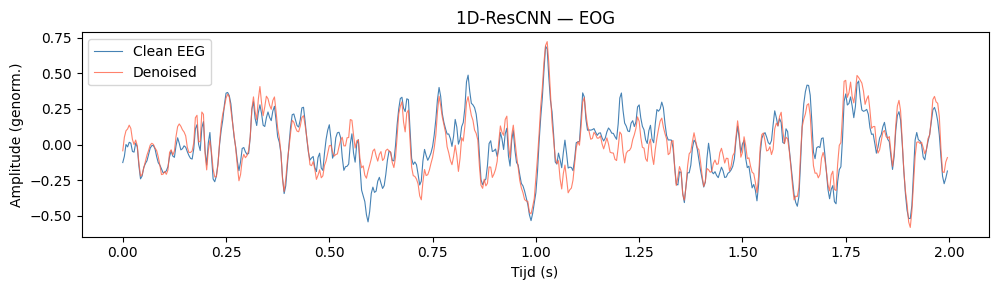

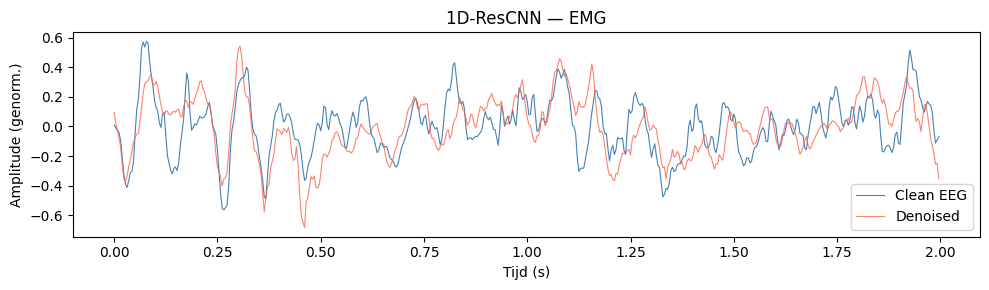

In [13]:
# train a model using the best params Optuna found to clean EOG
final_eog_model, final_eog_rrmse = train_rescnn(
    noisy_eog_train, clean_eog_train, noisy_eog_val, clean_eog_val,
    **study_eog.best_params, epochs=50
)
# let this model clean unseen test data
denoised_eog_test = rescnn_denoise(final_eog_model, noisy_eog_test)
# grade it
evaluate(clean_eog_test, denoised_eog_test, "ResCNN — EOG")

# train a model using the best params Optuna found to clean EMG
final_emg_model, final_emg_rrmse = train_rescnn(
    noisy_emg_train, clean_emg_train, noisy_emg_val, clean_emg_val,
    **study_emg.best_params, epochs=50
)
# let this model clean unseen test data
denoised_emg_test = rescnn_denoise(final_emg_model, noisy_emg_test)
# grade it
evaluate(clean_emg_test, denoised_emg_test, "ResCNN — EMG")


# plot the results
plot_denoising(clean_eog_test, denoised_eog_test, "1D-ResCNN — EOG")
plot_denoising(clean_emg_test, denoised_emg_test, "1D-ResCNN — EMG")

#### RESULT

The 1D-ResCNN shows a strong performance in removing EOG artifacts. With an RRMSE of 0.4305 and a high correlation of 0.8803, the model successfully reconstructs a signal that closely resembles the clean EEG. The plot confirms this, showing the denoised signal accurately tracking the movement of the underlying clean EEG plot without significantly under- or overshooting. This success is to be expected: EOG generates large waveforms that contrast sharply with the faster activity of normal brain waves. Because the shape of an EOG artifact is so distinct and predictable, the neural network can easily identify the pattern and remove it without damaging the real EEG signal underneath.

For EMG artifacts, the model's performance is moderate, having an RRMSE of 0.5379 and a correlation of 0.7665. While the plot shows that the denoised signal successfully captures the general overall movement of the clean EEG, it struggles to perfectly reconstruct the finer fluctuations. This lower accuracy highlights a classic challenge in analyzing EEG data: EMG noise is fast, chaotic, and closely resembles the high-frequency neural activity. Because these two signals overlap so heavily on a single channel, the neural network struggles to tell them apart. To compensate, the model tends to smooth out the data, which explains the lower correlation compared to the easily identifiable EOG.

## Wavelet Thresholding

In [ ]:
import pywt
import numpy as np

def wavelet_denoise_signal(signal, wavelet='db4', level=4, threshold_mode='soft', threshold_factor=1.0):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    # Estimate noise sigma from finest detail coefficients using MAD
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = threshold_factor * sigma * np.sqrt(2 * np.log(len(signal)))
    new_coeffs = [coeffs[0]] + [pywt.threshold(c, threshold, mode=threshold_mode) for c in coeffs[1:]]
    return pywt.waverec(new_coeffs, wavelet)[:len(signal)]

def wavelet_denoise(noisy, wavelet='db4', level=4, threshold_mode='soft', threshold_factor=1.0):
    return np.array([wavelet_denoise_signal(s, wavelet, level, threshold_mode, threshold_factor) for s in noisy])

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_wavelet_objective(noisy_val, clean_val):
    def objective(trial):
        wavelet          = trial.suggest_categorical('wavelet', ['db4', 'db6', 'db8', 'sym4', 'sym6', 'coif1', 'coif2'])
        level            = trial.suggest_int('level', 2, 6)
        threshold_mode   = trial.suggest_categorical('threshold_mode', ['soft', 'hard'])
        threshold_factor = trial.suggest_float('threshold_factor', 0.5, 3.0)
        denoised = wavelet_denoise(noisy_val, wavelet, level, threshold_mode, threshold_factor)
        return np.sqrt(np.mean((clean_val - denoised)**2) / np.mean(clean_val**2))
    return objective

### Optuna for hyperparameter tuning

c:\Users\benja\AppData\Local\Programs\Python\Python310\lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 6 is too high: all coefficients will experience boundary effects.
  warnings.warn(


EOG beste params: {'wavelet': 'db6', 'level': 4, 'threshold_mode': 'hard', 'threshold_factor': 0.508394706556329}
EOG beste RRMSE:  1.5220344066619873
EMG beste params: {'wavelet': 'db6', 'level': 3, 'threshold_mode': 'soft', 'threshold_factor': 2.8009707787016187}
EMG beste RRMSE:  0.8848788142204285
Wavelet Thresholding - EOG - RRMSE: 1.5215 | Correlatie: 0.4973
Wavelet Thresholding - EMG - RRMSE: 0.8893 | Correlatie: 0.6261


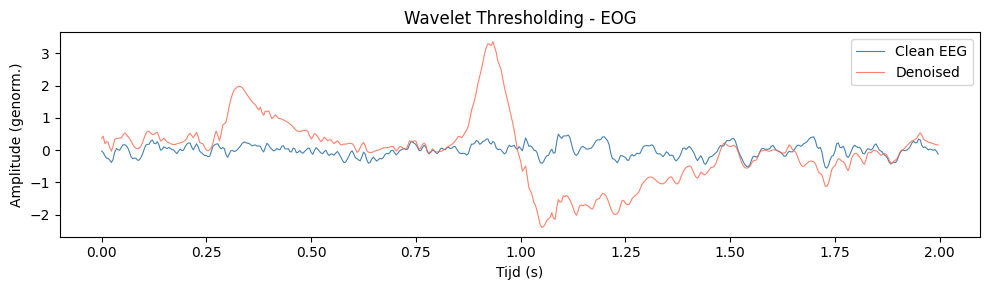

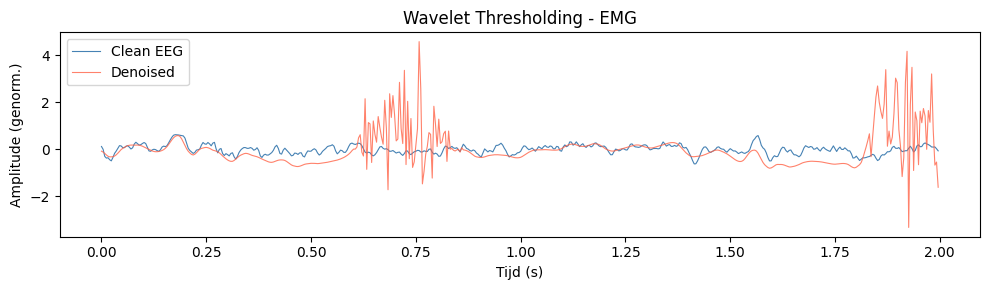

In [ ]:
study_wt_eog = optuna.create_study(direction='minimize')
study_wt_eog.optimize(make_wavelet_objective(noisy_eog_val, clean_eog_val), n_trials=30)

study_wt_emg = optuna.create_study(direction='minimize')
study_wt_emg.optimize(make_wavelet_objective(noisy_emg_val, clean_emg_val), n_trials=30)

print("EOG beste params:", study_wt_eog.best_params)
print("EOG beste RRMSE: ", study_wt_eog.best_value)
print("EMG beste params:", study_wt_emg.best_params)
print("EMG beste RRMSE: ", study_wt_emg.best_value)

# Evaluate on test set with best hyperparameters
denoised_wt_eog_test = wavelet_denoise(noisy_eog_test, **study_wt_eog.best_params)
evaluate(clean_eog_test, denoised_wt_eog_test, "Wavelet Thresholding - EOG")

denoised_wt_emg_test = wavelet_denoise(noisy_emg_test, **study_wt_emg.best_params)
evaluate(clean_emg_test, denoised_wt_emg_test, "Wavelet Thresholding - EMG")

# Plot denoised vs clean
plot_denoising(clean_eog_test, denoised_wt_eog_test, "Wavelet Thresholding - EOG")
plot_denoising(clean_emg_test, denoised_wt_emg_test, "Wavelet Thresholding - EMG")

### Result

Wavelet Thresholding performs poorly for both artifact types, and is the weakest method for EOG. For EOG, an RRMSE of 1.5215 is the highest of all three methods, the denoised signal is further from clean EEG than the noisy input, though a correlation of 0.4973 is notably the best across all methods for EOG, meaning the waveform shape is partially preserved even if the amplitude is not well recovered. For EMG, an RRMSE of 0.8893 and correlation of 0.6261 are marginally worse than ICA on RRMSE but better on correlation.

The disconnect between RRMSE and correlation for EOG is telling: the wavelet threshold aggressively zeroes out large-amplitude low-frequency coefficients (where EOG energy sits), which distorts the signal energy (raising RRMSE) while still preserving some of the underlying EEG morphology (maintaining correlation). EMG broadband noise overlaps with high-frequency EEG content, so neither soft nor hard thresholding can cleanly separate the two. As a single-channel method it is more applicable here than ICA, but without a reference channel it cannot distinguish artifact from neural signal in overlapping frequency bands.

## Kalman Filter

In [ ]:
import numpy as np

def kalman_denoise_signal(signal, Q=1e-3, R=0.1):
    """
    Scalar Kalman filter with a random-walk state model (A=1, H=1).
    Q: process noise variance (how fast the true signal can change)
    R: measurement noise variance (sensor/artifact noise level)
    """
    n = len(signal)
    x = np.empty(n)
    P = 1.0  # initial error covariance

    x_pred = signal[0]
    for t in range(n):
        # Predict
        P_pred = P + Q
        # Update
        K = P_pred / (P_pred + R)
        x[t] = x_pred + K * (signal[t] - x_pred)
        P = (1.0 - K) * P_pred
        x_pred = x[t]

    return x

def kalman_denoise(noisy, Q=1e-3, R=0.1):
    return np.array([kalman_denoise_signal(s, Q, R) for s in noisy])

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_kalman_objective(noisy_val, clean_val):
    def objective(trial):
        Q = trial.suggest_float('Q', 1e-5, 1e-1, log=True)
        R = trial.suggest_float('R', 1e-3, 10.0, log=True)
        denoised = kalman_denoise(noisy_val, Q, R)
        return np.sqrt(np.mean((clean_val - denoised)**2) / np.mean(clean_val**2))
    return objective

### Optuna for hyperparameter tuning

EOG beste params: {'Q': 1.0319866184929084e-05, 'R': 9.998143613194635}
EOG beste RRMSE:  1.152086639987527
EMG beste params: {'Q': 0.001245665479103407, 'R': 0.009778424252623581}
EMG beste RRMSE:  0.9164029740778399
Kalman Filter - EOG - RRMSE: 1.1520 | Correlatie: 0.0440
Kalman Filter - EMG - RRMSE: 0.9159 | Correlatie: 0.5824


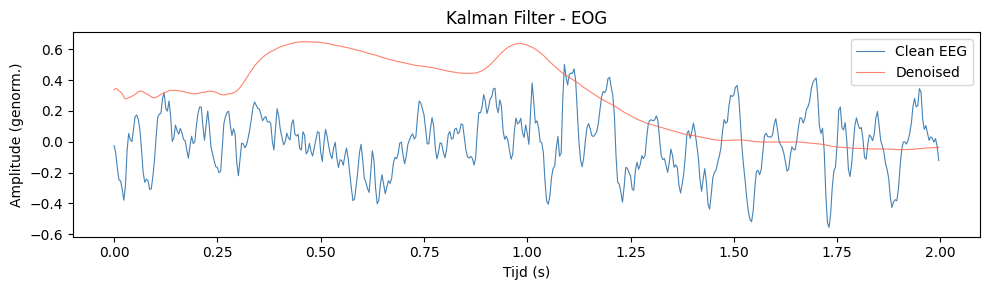

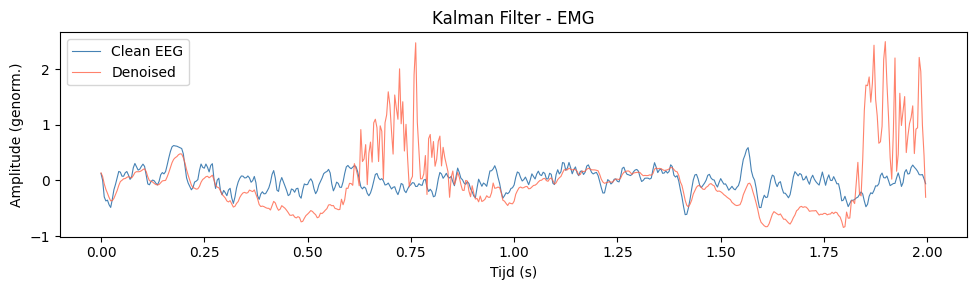

In [ ]:
study_kf_eog = optuna.create_study(direction='minimize')
study_kf_eog.optimize(make_kalman_objective(noisy_eog_val, clean_eog_val), n_trials=30)

study_kf_emg = optuna.create_study(direction='minimize')
study_kf_emg.optimize(make_kalman_objective(noisy_emg_val, clean_emg_val), n_trials=30)

print("EOG beste params:", study_kf_eog.best_params)
print("EOG beste RRMSE: ", study_kf_eog.best_value)
print("EMG beste params:", study_kf_emg.best_params)
print("EMG beste RRMSE: ", study_kf_emg.best_value)

# Evaluate on test set with best hyperparameters
denoised_kf_eog_test = kalman_denoise(noisy_eog_test, **study_kf_eog.best_params)
evaluate(clean_eog_test, denoised_kf_eog_test, "Kalman Filter - EOG")

denoised_kf_emg_test = kalman_denoise(noisy_emg_test, **study_kf_emg.best_params)
evaluate(clean_emg_test, denoised_kf_emg_test, "Kalman Filter - EMG")

# Plot denoised vs clean
plot_denoising(clean_eog_test, denoised_kf_eog_test, "Kalman Filter - EOG")
plot_denoising(clean_emg_test, denoised_kf_emg_test, "Kalman Filter - EMG")

### Result

The Kalman Filter achieves the best RRMSE for EOG among all three methods, but at the cost of nearly zero correlation. For EOG, an RRMSE of 1.1520 is the lowest of the three (though still above 1, meaning the output remains worse than the noisy input), while a correlation of only 0.0440 indicates the filter has effectively smoothed away nearly all EEG structure along with the artifact. Optuna selected a very small Q (≈1e-5) and a very large R (≈10), which drives the Kalman gain close to zero, the filter trusts its flat prediction almost entirely and barely follows the measured signal, producing a near-constant output. For EMG, an RRMSE of 0.9159 and correlation of 0.5824 are the weakest of the three methods on RRMSE, though correlation is marginally above ICA.

The Kalman filter's random-walk state model is too simplistic for EEG: it assumes the signal changes only slowly, which collapses to excessive low-pass smoothing when Q/R is small. It cannot distinguish between artifact and neural oscillations in this static offline form. Its real value would emerge in a real-time setting where Q and R are estimated adaptively from the signal statistics, rather than tuned once offline.

## Method Comparison

 Method Noise  RRMSE  Correlation
    ICA   EOG 1.2570       0.1157
    ICA   EMG 0.8739       0.5754
Wavelet   EOG 1.5215       0.4973
Wavelet   EMG 0.8893       0.6261
 Kalman   EOG 1.1520       0.0440
 Kalman   EMG 0.9159       0.5824


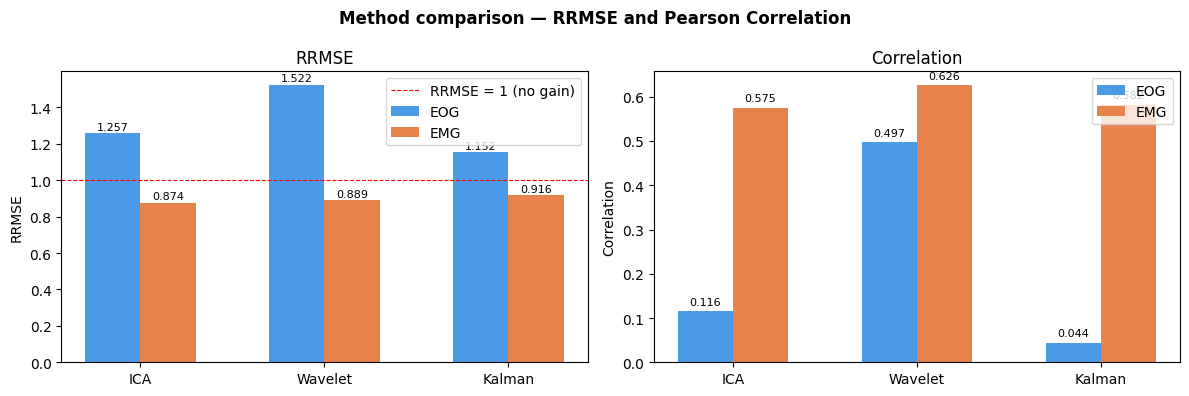

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def rrmse(clean, denoised):
    return np.sqrt(np.mean((clean - denoised) ** 2) / np.mean(clean ** 2))

def pearson(clean, denoised):
    return np.mean([np.corrcoef(clean[i], denoised[i])[0, 1] for i in range(len(clean))])

results = {
    "Method":      ["ICA",               "ICA",               "Wavelet",              "Wavelet",              "Kalman",             "Kalman"],
    "Noise":       ["EOG",               "EMG",               "EOG",                  "EMG",                  "EOG",                "EMG"],
    "RRMSE":       [rrmse(clean_eog_test, denoised_eog_test),    rrmse(clean_emg_test, denoised_emg_test),
                    rrmse(clean_eog_test, denoised_wt_eog_test), rrmse(clean_emg_test, denoised_wt_emg_test),
                    rrmse(clean_eog_test, denoised_kf_eog_test), rrmse(clean_emg_test, denoised_kf_emg_test)],
    "Correlation": [pearson(clean_eog_test, denoised_eog_test),    pearson(clean_emg_test, denoised_emg_test),
                    pearson(clean_eog_test, denoised_wt_eog_test), pearson(clean_emg_test, denoised_wt_emg_test),
                    pearson(clean_eog_test, denoised_kf_eog_test), pearson(clean_emg_test, denoised_kf_emg_test)],
}

df = pd.DataFrame(results)
df["RRMSE"]       = df["RRMSE"].round(4)
df["Correlation"] = df["Correlation"].round(4)
print(df.to_string(index=False))

# Bar charts
methods = ["ICA", "Wavelet", "Kalman"]
x = np.arange(len(methods))
width = 0.3
colors_eog = "#4C9BE8"
colors_emg = "#E8834C"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["RRMSE", "Correlation"]):
    eog_vals = [df.loc[(df.Method == m) & (df.Noise == "EOG"), metric].values[0] for m in methods]
    emg_vals = [df.loc[(df.Method == m) & (df.Noise == "EMG"), metric].values[0] for m in methods]

    bars_eog = ax.bar(x - width / 2, eog_vals, width, label="EOG", color=colors_eog)
    bars_emg = ax.bar(x + width / 2, emg_vals, width, label="EMG", color=colors_emg)

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend()

    for bar in bars_eog + bars_emg:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

    if metric == "RRMSE":
        ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, label="RRMSE = 1 (no gain)")
        ax.legend()

plt.suptitle("Method comparison - RRMSE and Pearson Correlation", fontweight="bold")
plt.tight_layout()
plt.show()

### Best & Worst Case per Method

For each method and noise type, the epoch with the lowest per-epoch RRMSE (best case) and the highest per-epoch RRMSE (worst case) are shown side by side. This reveals the ceiling and floor of each method rather than a single arbitrary example.

In [ ]:
def plot_best_worst(clean, denoised, label="", fs=256):
    per_epoch_rrmse = np.sqrt(
        np.mean((clean - denoised) ** 2, axis=1) / np.mean(clean ** 2, axis=1)
    )
    best_idx  = int(np.argmin(per_epoch_rrmse))
    worst_idx = int(np.argmax(per_epoch_rrmse))

    t = np.arange(clean.shape[1]) / fs
    fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

    for ax, idx, case in zip(axes, [best_idx, worst_idx], ["Best", "Worst"]):
        ax.plot(t, clean[idx],    color="steelblue", linewidth=0.8, label="Clean EEG")
        ax.plot(t, denoised[idx], color="tomato",    linewidth=0.8, label="Denoised", alpha=0.8)
        ax.set_title(f"{label} - {case} epoch (idx={idx}, RRMSE={per_epoch_rrmse[idx]:.3f})")
        ax.set_xlabel("Tijd (s)")
        ax.set_ylabel("Amplitude (genorm.)")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

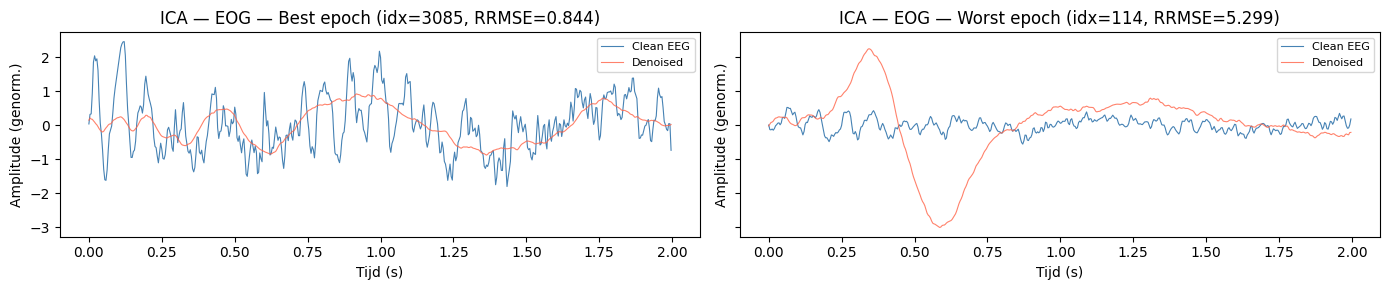

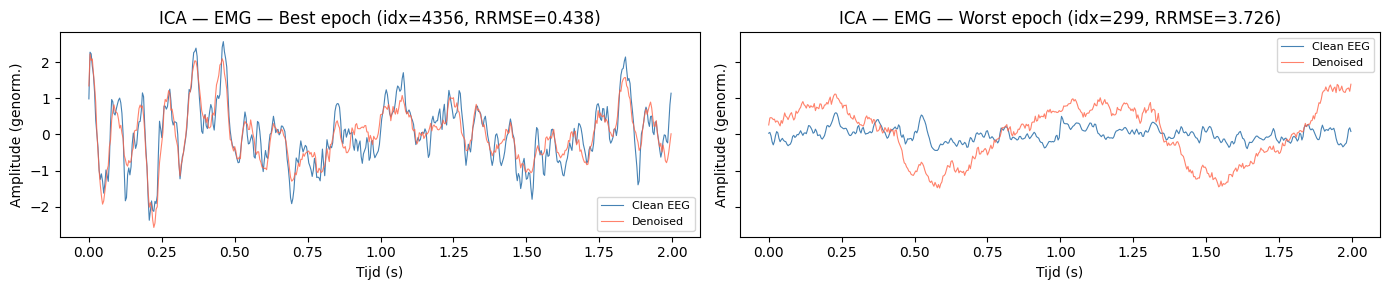

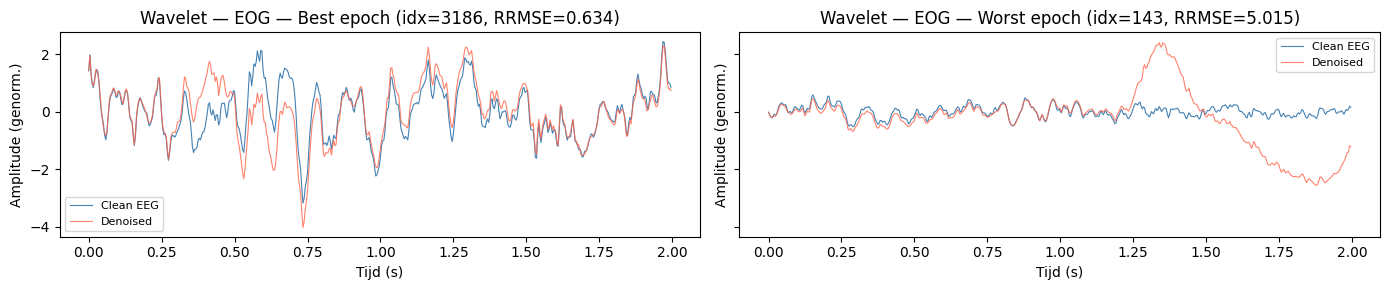

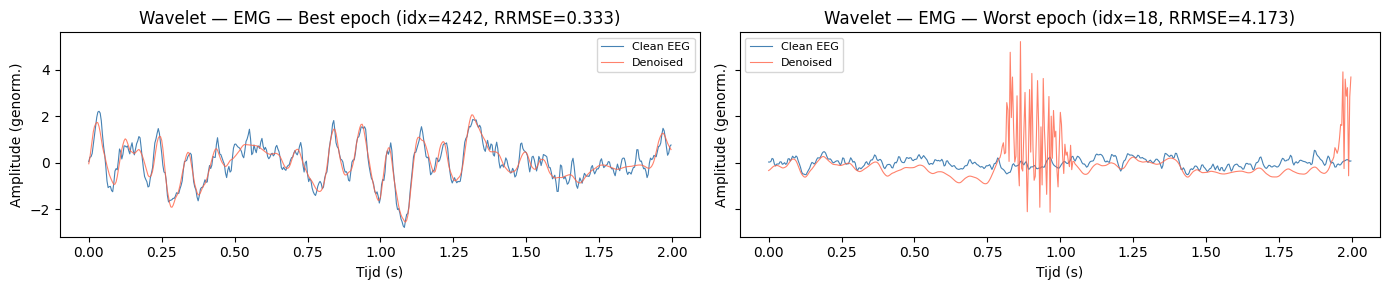

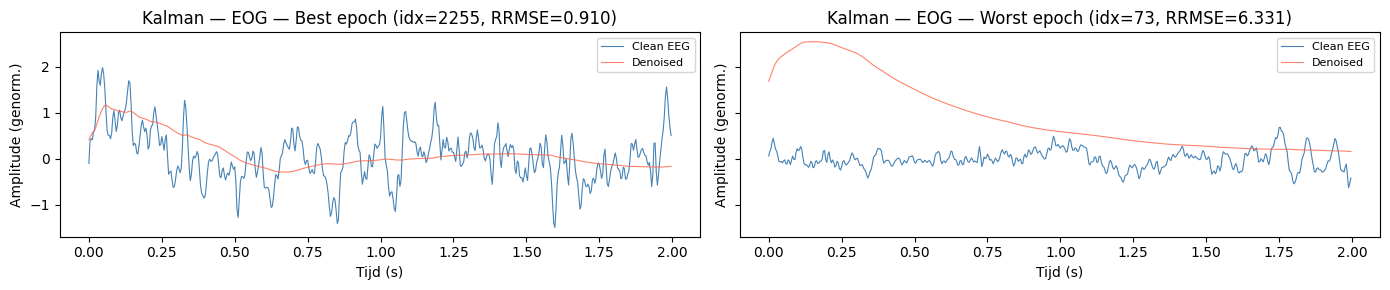

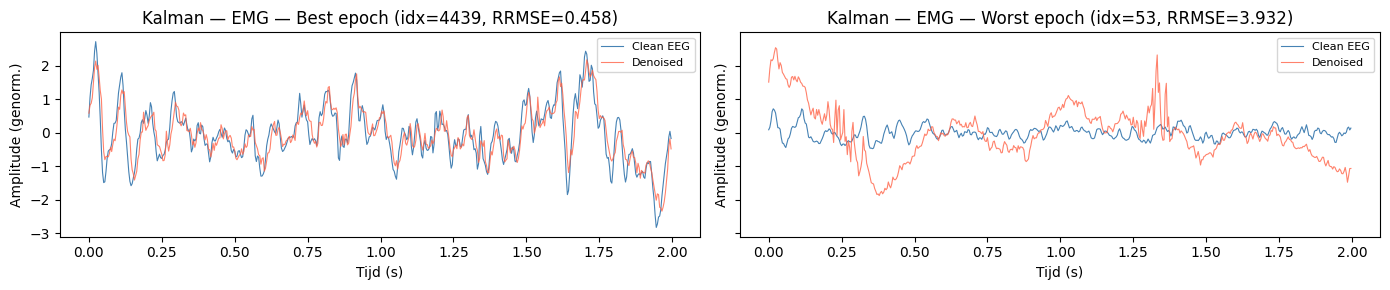

In [ ]:
# Best & worst epoch per method x noise type
pairs = [
    ("ICA",     "EOG", clean_eog_test, denoised_eog_test),
    ("ICA",     "EMG", clean_emg_test, denoised_emg_test),
    ("Wavelet", "EOG", clean_eog_test, denoised_wt_eog_test),
    ("Wavelet", "EMG", clean_emg_test, denoised_wt_emg_test),
    ("Kalman",  "EOG", clean_eog_test, denoised_kf_eog_test),
    ("Kalman",  "EMG", clean_emg_test, denoised_kf_emg_test),
]

for method, noise, clean, denoised in pairs:
    plot_best_worst(clean, denoised, label=f"{method} - {noise}")

# Denoising data Real-Time

In [ ]:
import time

# generator function to simulate real-time streaming of EEG data
def realtime_stream(noisy_epochs, ref_epochs, fs=256, simulate_delay=False):
    for ep in range(len(noisy_epochs)):
        for sample_idx in range(noisy_epochs.shape[1]):
            eeg_sample = noisy_epochs[ep, sample_idx]
            ref_sample = ref_epochs[ep, sample_idx]
            if simulate_delay:
                time.sleep(1 / fs)
            yield eeg_sample, ref_sample, ep, sample_idx

## Real-time Bandpass Filter

Real-Time Bandpass Filter is a classical signal processing method that keeps only the frequencies within a defined range and removes everything outside it. It processes samples one by one, making it suitable for real-time use without requiring a reference signal.

For EEG denoising, it targets the frequency difference between EEG and artifacts: EOG is low-frequency, EMG is high-frequency. However, since EEG and artifacts overlap in frequency, the filter cannot cleanly separate them, making this a simple but limited baseline method.

In [ ]:
from scipy.signal import butter, sosfilt, sosfilt_zi

def bandpass_realtime(noisy_epochs, low_cut=1.0, high_cut=40.0, order=4, fs=256):
    sos = butter(order, [low_cut, high_cut], btype='bandpass', fs=fs, output='sos')
    zi = sosfilt_zi(sos) * noisy_epochs[0, 0]
    denoised = np.zeros_like(noisy_epochs)

    start = time.time()
    for ep in range(len(noisy_epochs)):
        denoised[ep], zi = sosfilt(sos, noisy_epochs[ep], zi=zi)

    elapsed = time.time() - start
    budget = noisy_epochs.size / 256
    return denoised

In [ ]:
def make_objective_bandpass(noisy_val, clean_val):
    def objective(trial):
        low_cut  = trial.suggest_float('low_cut', 0.5, 8.0)
        high_cut = trial.suggest_float('high_cut', 20.0, 80.0)
        order    = trial.suggest_int('order', 2, 8)
        denoised = bandpass_realtime(noisy_val, low_cut=low_cut, high_cut=high_cut, order=order)
        return np.sqrt(np.mean((clean_val - denoised)**2) / np.mean(clean_val**2))
    return objective

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_bp_eog = optuna.create_study(direction='minimize')
study_bp_eog.optimize(make_objective_bandpass(noisy_eog_val, clean_eog_val), n_trials=20)
print("EOG best params:", study_bp_eog.best_params)
print("EOG best RRMSE: ", study_bp_eog.best_value)

study_bp_emg = optuna.create_study(direction='minimize')
study_bp_emg.optimize(make_objective_bandpass(noisy_emg_val, clean_emg_val), n_trials=20)
print("EMG best params:", study_bp_emg.best_params)
print("EMG best RRMSE: ", study_bp_emg.best_value)

EOG best params: {'low_cut': 6.33079993324076, 'high_cut': 73.36751535269681, 'order': 2}
EOG best RRMSE:  0.9363820259152059
EMG best params: {'low_cut': 1.4939435089446556, 'high_cut': 20.406534857187367, 'order': 2}
EMG best RRMSE:  1.0362238024211061


Bandpass — EOG — RRMSE: 0.9447 | Correlatie: 0.4495


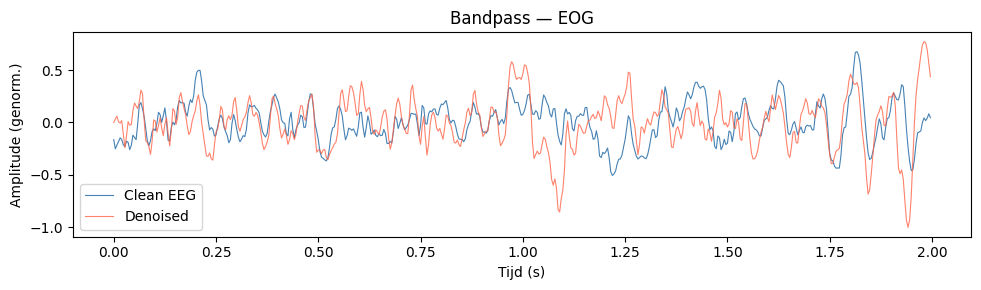

Bandpass — EMG — RRMSE: 1.0355 | Correlatie: 0.4525


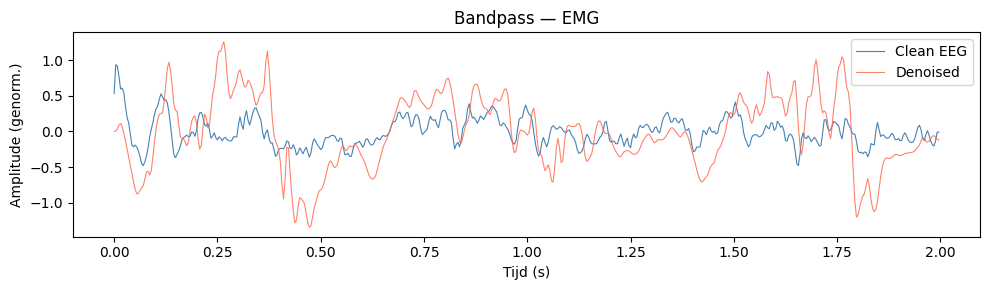

In [ ]:
denoised_bp_eog = bandpass_realtime(noisy_eog_test, **study_bp_eog.best_params)
evaluate(clean_eog_test, denoised_bp_eog, "Bandpass — EOG")
plot_denoising(clean_eog_test, denoised_bp_eog, "Bandpass — EOG")

denoised_bp_emg = bandpass_realtime(noisy_emg_test, **study_bp_emg.best_params)
evaluate(clean_emg_test, denoised_bp_emg, "Bandpass — EMG")
plot_denoising(clean_emg_test, denoised_bp_emg, "Bandpass — EMG")

### Result 

The bandpass filter performs poorly on both artifact types, with RRMSE values near or above 1.0 and correlations around 0.45. This confirms the expected limitation: since EEG and artifacts overlap in frequency, the filter cannot cleanly separate them without also distorting the EEG signal itself. The plots clearly show the denoised signal diverging significantly from the clean EEG, particularly for EMG where the RRMSE exceeds 1.0, meaning the filtered signal is worse than the original noisy input. These results are consistent with the bandpass filter's role as a simple baseline, and motivate the use of more sophisticated methods.

## Kalman Filter - Real-Time Denoising

The Kalman filter is the only method of the three that is naturally suited to real-time processing: it is **causal** (each output depends only on the current and past samples, never future ones) and maintains a running state estimate that is updated one sample at a time, making it compatible with the streaming generator.

The same Q and R values found during offline hyperparameter tuning are reused here. The filter state is reset at the start of each new epoch, which mirrors a real-time system processing independent EEG segments. The RRMSE and correlation should be identical to the offline result, confirming that the sample-by-sample implementation is equivalent.

Kalman real-time - EOG - RRMSE: 1.1520 | Correlatie: 0.0440
Kalman real-time - EMG - RRMSE: 0.9159 | Correlatie: 0.5824


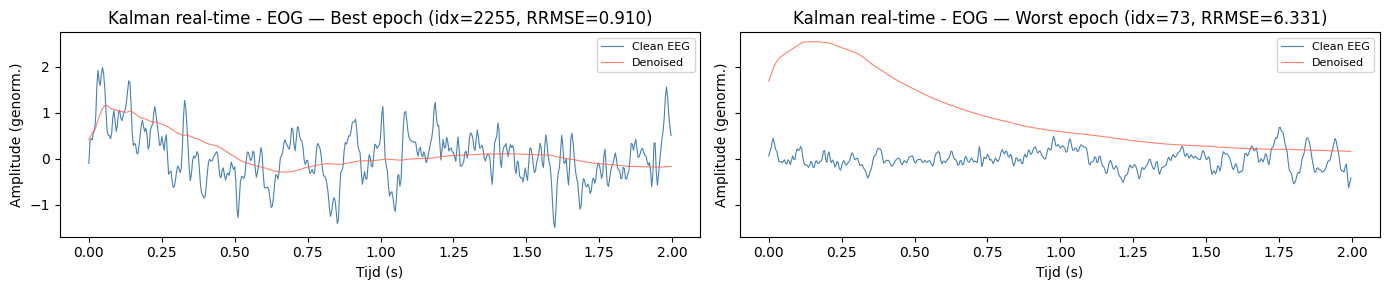

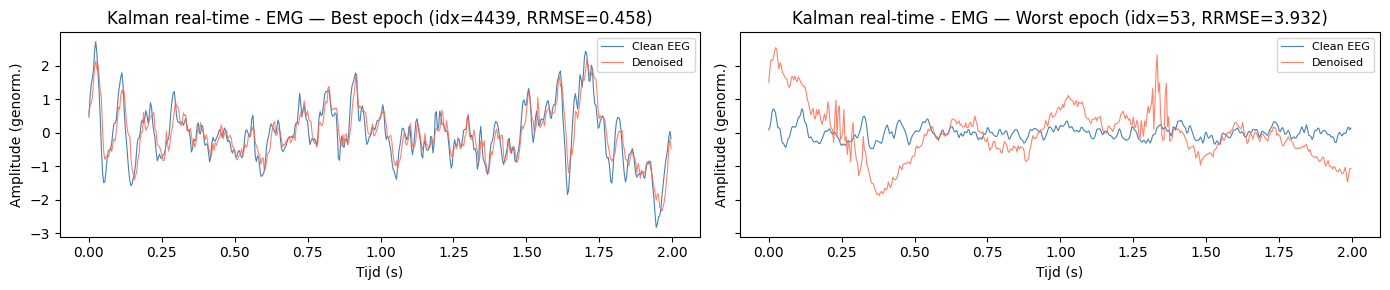

In [ ]:
def kalman_realtime(noisy_epochs, Q, R):
    """Run the Kalman filter sample-by-sample via the realtime_stream generator.
    State is reset at the start of each new epoch, mirroring a real-time
    system that processes independent EEG segments.
    """
    n_epochs, n_samples = noisy_epochs.shape
    denoised = np.zeros((n_epochs, n_samples))

    x_pred, P = 0.0, 1.0

    for eeg_sample, _ref, ep, sample_idx in realtime_stream(noisy_epochs, noisy_epochs):
        if sample_idx == 0:           # new epoch, reset filter state
            x_pred = float(eeg_sample)
            P = 1.0

        P_pred = P + Q
        K      = P_pred / (P_pred + R)
        x_hat  = x_pred + K * (eeg_sample - x_pred)
        P      = (1.0 - K) * P_pred
        x_pred = x_hat

        denoised[ep, sample_idx] = x_hat

    return denoised


# Use best Q/R found during offline tuning
rt_denoised_eog = kalman_realtime(noisy_eog_test, **study_kf_eog.best_params)
rt_denoised_emg = kalman_realtime(noisy_emg_test, **study_kf_emg.best_params)

evaluate(clean_eog_test, rt_denoised_eog, "Kalman real-time - EOG")
evaluate(clean_emg_test, rt_denoised_emg, "Kalman real-time - EMG")

plot_best_worst(clean_eog_test, rt_denoised_eog, "Kalman real-time - EOG")
plot_best_worst(clean_emg_test, rt_denoised_emg, "Kalman real-time - EMG")

### Result

The real-time Kalman filter produces results identical to the offline version: EOG RRMSE of 1.1520 with a correlation of 0.0440, and EMG RRMSE of 0.9159 with a correlation of 0.5824. This confirms that the sample-by-sample streaming implementation is mathematically equivalent to the batch implementation, processing one sample at a time through the generator introduces no approximation.

The key takeaway is that while the denoising quality is the same as offline, the Kalman filter is the only method of the three that can realistically operate in this way. Wavelet thresholding requires the full epoch before the DWT can be computed, and ICA requires a full data matrix to fit, neither can produce a denoised output at each individual sample. The Kalman filter therefore stands out not because it achieves better RRMSE or correlation, but because it is structurally compatible with real-time EEG processing pipelines.